In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

### Comparacion

In [50]:
KNN = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_knn%20(1).csv')
RandomFR = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_rfr.csv')
RotationFR = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_rotationForest.csv')
RotationFR_SL = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_rotationForest_sinLeakage.csv')
RotationFR_SL_NL = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_rotationForest_sinLeakage_NoLineal.csv')
xgb = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_xgb.csv')

In [51]:
df = pd.merge(KNN, RandomFR, on='ID', how='inner', suffixes=('_knn', '_rfr'))
df = df.merge(RotationFR, on='ID', how='inner', suffixes=('_rfr', '_rfrot'))
df = df.merge(RotationFR_SL, on='ID', how='inner', suffixes=('_rfrot', '_rfrot_sl'))
df = df.merge(RotationFR_SL_NL, on='ID', how='inner', suffixes=('_rfrot_sl', '_rfrot_sl_nl'))
df = df.merge(xgb, on='ID', how='inner', suffixes=('_rfrot_sl_nl', '_xgb'))

In [52]:
df.columns = [i.split('track_popularity_')[1] if i.split('track_popularity_')[0]=='' else i for i in df.columns]

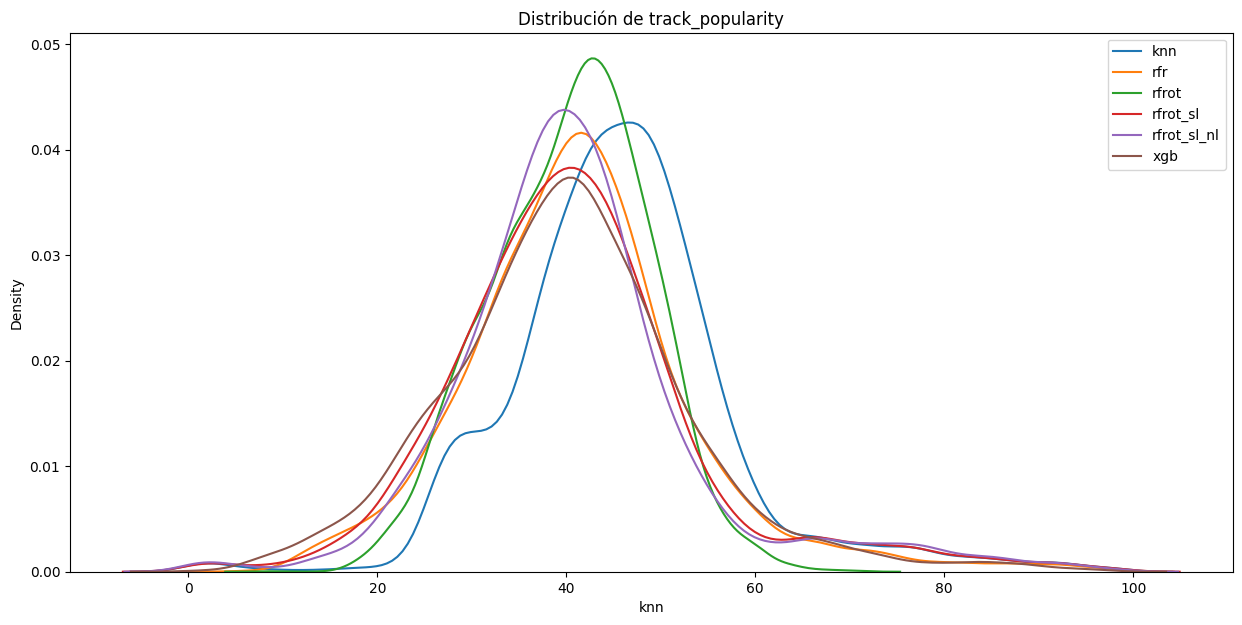

In [53]:
plt.figure(figsize=(15, 7)) # Increased figure size for better legend placement
for col in df.drop(columns=['ID']).columns:
  sns.kdeplot(df[col], label=f'{col}', shade=False)
plt.title(f'Distribución de track_popularity')
plt.legend()
plt.show()

### Inventado

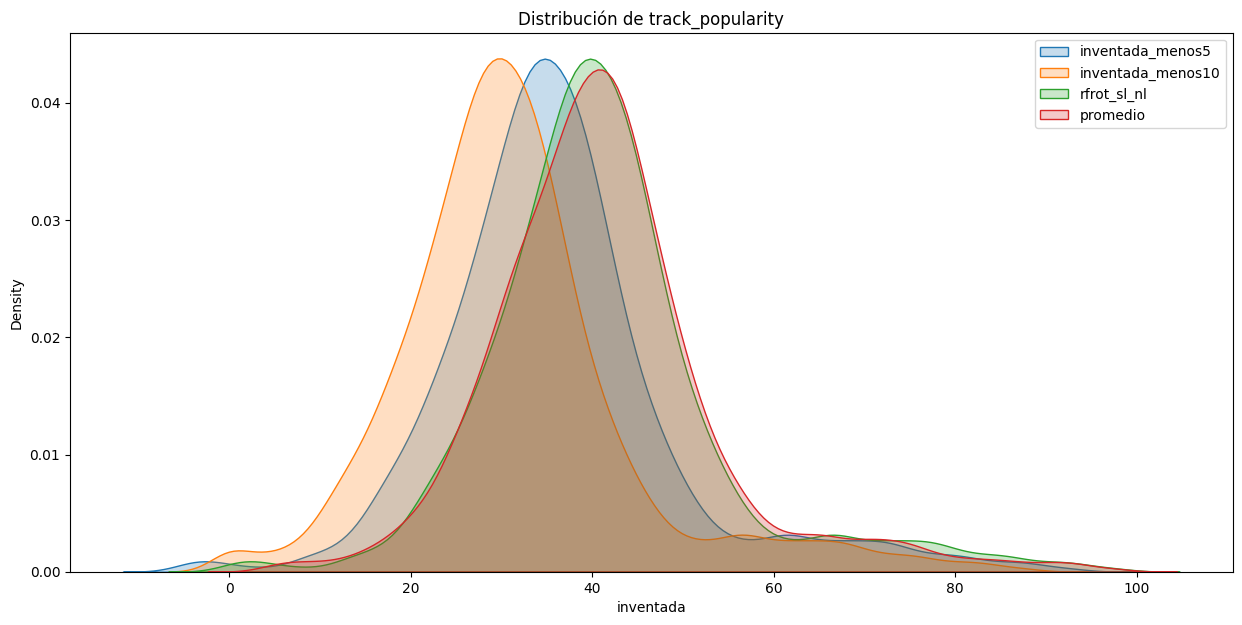

In [54]:
plt.figure(figsize=(15, 7))

# Corremos el mejor Rotation Forest
df['inventada'] = df['rfrot_sl_nl']-5

# Promediamos los Rotation Forest
df['promedio_best3'] = (df['rfrot_sl_nl']+df['rfrot_sl']+df['rfr'])/3

# Corremos mas todavia el mejor Rotation Forest
df['inventada_menos10'] = df['rfrot_sl_nl']-10
df['inventada_menos10'] = df['inventada_menos10'].apply(lambda x: 0 if x < 0 else x)

sns.kdeplot(df['inventada'], label=f'inventada_menos5', shade=True)
sns.kdeplot(df['inventada_menos10'], label=f'inventada_menos10', shade=True)
sns.kdeplot(df['rfrot_sl_nl'], label=f'rfrot_sl_nl', shade=True)
sns.kdeplot(df['promedio_best3'], label=f'promedio', shade=True)

plt.title(f'Distribución de track_popularity')
plt.legend()
plt.show()

Best RotationForest - 5 -> 0,29449

In [55]:
# df[['ID','inventada']].to_csv('probando_inventada.csv', index=False)

Best RotationForest - 10 -> 0,28478

In [56]:
# df[['ID','inventada_menos10']].to_csv('BestRotationForest_menos10.csv', index=False)

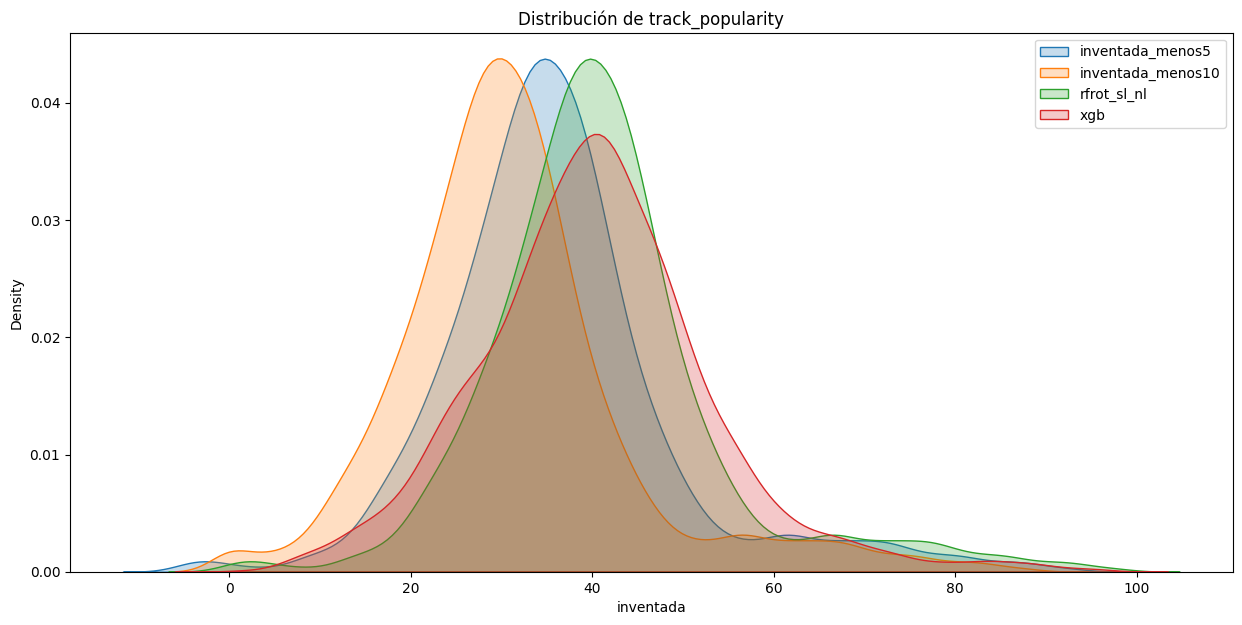

In [57]:
plt.figure(figsize=(15, 7))

sns.kdeplot(df['inventada'], label=f'inventada_menos5', shade=True)
sns.kdeplot(df['inventada_menos10'], label=f'inventada_menos10', shade=True)
sns.kdeplot(df['rfrot_sl_nl'], label=f'rfrot_sl_nl', shade=True)
sns.kdeplot(df['xgb'], label=f'xgb', shade=True)

plt.title(f'Distribución de track_popularity')
plt.legend()
plt.show()

XGBoost -> 0,21103

XGBoost corrida 4,5 unidades a la izquierda -> 0,27078

In [58]:
df['inventada_xgb'] = df['xgb'] - 4.5
df['inventada_xgb'] = df['inventada_xgb'].apply(lambda x: 2.5 if x < 0 else x)
# df[['ID','inventada_xgb']].to_csv('probando_inventada_xgb.csv', index=False)

Sumamos modelos catboost

In [59]:
catboost0 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_catboost0.csv')
catboost1_reduced = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_catboost1_reduced.csv')

In [60]:
df = df.merge(catboost0, on='ID', how='inner', suffixes=('_rfrot_sl_nl', '_catboost0'))
df = df.merge(catboost1_reduced, on='ID', how='inner', suffixes=('_catboost0', '_catboost1_reduced'))

In [61]:
df.columns = [i.split('track_popularity_')[1] if i.split('track_popularity_')[0]=='' else i for i in df.columns]

### Comparaciones

In [73]:
catboost_with_leakage = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_with_leakage.csv')
submission_catboost1_reduced_inventada = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_catboost1_reduced_inventada.csv')
catboost_full_plus_with_leakage_track_id_moved65 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_full_plus_with_leakage_track_id_moved6.5.csv')
catboost_full_track_id_imputation_moved_625 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_full_track_id_imputation_moved-6.25.csv')
submission_catboost0 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_catboost0.csv')

In [74]:
catboost_with_leakage['track_popularity'] = catboost_with_leakage['track_popularity'] + 6
catboost_full_track_id_imputation_moved_625['track_popularity'] = catboost_full_track_id_imputation_moved_625['track_popularity'] + 6.25
catboost_full_plus_with_leakage_track_id_moved65['track_popularity'] = catboost_full_plus_with_leakage_track_id_moved65['track_popularity'] + 6.5

In [75]:
df2 = df.merge(catboost_with_leakage, on='ID', how='inner', suffixes=('_rfrot_sl_nl', '_catboost_with_leakage'))
df2 = df2.merge(submission_catboost1_reduced_inventada, on='ID', how='inner', suffixes=('_catboost_with_leakage', '_catboost1_red_inv'))
df2 = df2.merge(catboost_full_plus_with_leakage_track_id_moved65, on='ID', how='inner', suffixes=('_catboost1_red_inv', '_catboost_leakage_track_id_6.5'))
df2 = df2.merge(catboost_full_track_id_imputation_moved_625, on='ID', how='inner', suffixes=('_catboost_leakage_track_id_6.5', '_catboost_track_id_imputation_6.25'))

df2.columns = [i.split('track_popularity_')[1] if i.split('track_popularity_')[0]=='' else i for i in df2.columns]

In [76]:
df2.drop(columns=['ID','inventada',	'promedio_best3',	'inventada_menos10',	'inventada_xgb'], inplace=True)

In [80]:
import itertools

columns = df2.columns.tolist()

# Generate all combinations of 3 columns
column_combinations = list(itertools.combinations(columns, 3))

print(f"Total combinations of 3 columns: {len(column_combinations)}\n")

results = []

for combo in column_combinations:
    selected_data = df2[list(combo)]

    # Calculate mean, median, and standard deviation for each row across the 3 columns
    mean_combo = selected_data.mean(axis=1)
    median_combo = selected_data.median(axis=1)
    std_combo = selected_data.std(axis=1)

    # Optionally, you can store these in a list of dictionaries for further analysis
    results.append({
        'combination': combo,
        'mean_of_means': mean_combo.mean(),
        'median_of_medians': median_combo.median(),
        'mean_of_std_devs': std_combo.mean()
    })

Total combinations of 3 columns: 220



In [83]:
df_results = pd.DataFrame(results)

In [86]:
df_results.sort_values(by='mean_of_means', ascending=True).head(15)

,combination,mean_of_means,median_of_medians,mean_of_std_devs
187,"(xgb, catboost0, catboost1_red_inv)",38.766125,37.331170,4.899263
123,"(rfrot, catboost0, catboost1_red_inv)",38.847420,37.623036,4.891054
208,"(catboost0, catboost1_red_inv, catboost_track_...",38.950438,37.229925,3.632016
204,"(catboost0, catboost_with_leakage, catboost1_r...",39.001927,37.542910,3.014117
151,"(rfrot_sl, catboost0, catboost1_red_inv)",39.007669,37.472797,4.870446
172,"(rfrot_sl_nl, catboost0, catboost1_red_inv)",39.086107,37.490972,4.794719
87,"(rfr, catboost0, catboost1_red_inv)",39.176216,37.542080,4.878125
115,"(rfrot, xgb, catboost0)",39.404776,39.406334,5.607505
189,"(xgb, catboost0, catboost_track_id_imputation_...",39.507793,37.858441,5.210167
201,"(catboost0, catboost1_reduced, catboost1_red_inv)",39.542102,37.904564,3.515832


In [87]:
# Generate all combinations of 4 columns
column_combinations_4 = list(itertools.combinations(columns, 4))

print(f"Total combinations of 4 columns: {len(column_combinations_4)}")

results_4 = []

for combo in column_combinations_4:
    selected_data = df2[list(combo)]

    # Calculate mean, median, and standard deviation for each row across the 4 columns
    mean_combo = selected_data.mean(axis=1)
    median_combo = selected_data.median(axis=1)
    std_combo = selected_data.std(axis=1)

    # Optionally, you can store these in a list of dictionaries for further analysis
    results_4.append({
        'combination': combo,
        'mean_of_means': mean_combo.mean(),
        'median_of_medians': median_combo.median(),
        'mean_of_std_devs': std_combo.mean()
    })

df_results4 = pd.DataFrame(results_4)

Total combinations of 4 columns: 495


In [89]:
df_results4.sort_values(by='mean_of_means', ascending=True).head(15)

,combination,mean_of_means,median_of_medians,mean_of_std_devs
336,"(rfrot, xgb, catboost0, catboost1_red_inv)",39.186301,38.475843,5.328544
468,"(xgb, catboost0, catboost1_red_inv, catboost_t...",39.263564,37.537608,4.911264
464,"(xgb, catboost0, catboost_with_leakage, catboo...",39.302181,37.904514,4.547237
392,"(rfrot_sl, xgb, catboost0, catboost1_red_inv)",39.306487,38.207812,5.041039
357,"(rfrot, catboost0, catboost1_red_inv, catboost...",39.324536,37.837925,4.958943
353,"(rfrot, catboost0, catboost_with_leakage, catb...",39.363153,38.125657,4.551217
427,"(rfrot_sl_nl, xgb, catboost0, catboost1_red_inv)",39.365316,38.198510,5.032444
300,"(rfrot, rfrot_sl, catboost0, catboost1_red_inv)",39.367459,38.693120,5.221734
321,"(rfrot, rfrot_sl_nl, catboost0, catboost1_red_...",39.426288,38.483666,5.297650
252,"(rfr, xgb, catboost0, catboost1_red_inv)",39.432898,38.395590,5.046763


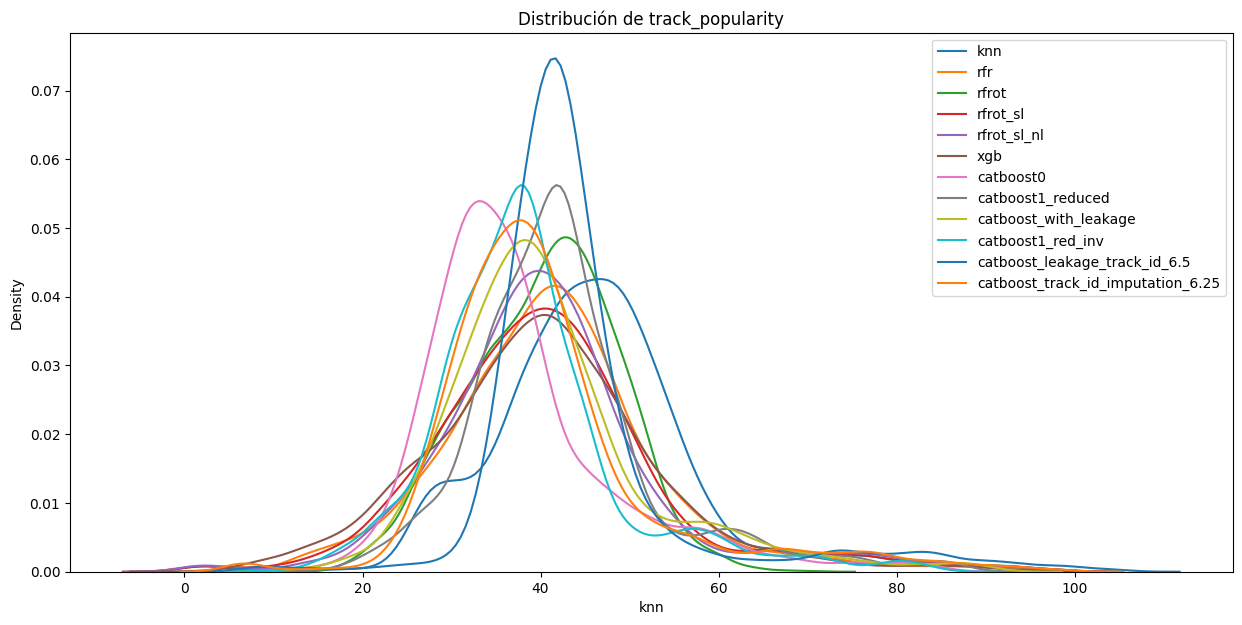

In [93]:
plt.figure(figsize=(15, 7))

for col in columns:
  sns.kdeplot(df2[col], label=f'{col}', shade=False)

plt.title(f'Distribución de track_popularity')
plt.legend()
plt.show()

### Mejor pred hasta 1/6/26

In [ ]:
df_best_pred = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_full_track_id_imputation_moved-6.25.csv')
df_best_pred['track_popularity'] = (df_best_pred['track_popularity'] + 6.25) - 7
df_best_pred['track_popularity'] = df_best_pred['track_popularity'].apply(lambda x: 0 if x < 0 else x)

# df_best_pred.to_csv('catboost_full_track_id_imputation_moved-7.csv', index=False)

### Promedio mejores predicciones (todas las de R^2 score mayor a 0,30)

Saco algunos de los Catboost movidos que son el mismo algoritmo

In [ ]:
import os
import pandas as pd

# Directory where the submission files are located
directory_path = '/content/'

# Get a dynamic list of relevant CSV files in the directory
# We'll consider files that contain 'submission' or 'catboost' in their name
# as these are typically the files with 'track_popularity' for averaging.
all_files_in_dir = os.listdir(directory_path)
relevant_csv_files = []
for f in all_files_in_dir:
    if f.endswith('.csv') and ('submission' in f or 'catboost' in f):
        relevant_csv_files.append(os.path.join(directory_path, f))

# Initialize a base dataframe for merging, typically with 'ID'
merged_df = None

print(f"Found {len(relevant_csv_files)} relevant CSV files to average:")
for file_path in relevant_csv_files:
    print(f"- {os.path.basename(file_path)}")
    try:
        temp_df = pd.read_csv(file_path)
        # Ensure 'ID' and 'track_popularity' columns exist
        if 'ID' in temp_df.columns and 'track_popularity' in temp_df.columns:
            # Rename track_popularity to avoid conflicts during merge
            col_name = f'track_popularity_{os.path.basename(file_path).replace(".csv", "")}'
            temp_df = temp_df[['ID', 'track_popularity']].rename(columns={'track_popularity': col_name})

            if merged_df is None:
                merged_df = temp_df
            else:
                # Perform an inner merge to ensure all IDs are common across submissions
                merged_df = pd.merge(merged_df, temp_df, on='ID', how='inner')
        else:
            print(f"Skipping {file_path} as it does not contain 'ID' or 'track_popularity' columns.")
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

if merged_df is not None:
    # Get all columns that start with 'track_popularity_'
    popularity_cols = [col for col in merged_df.columns if col.startswith('track_popularity_')]

    if popularity_cols:
        # Calculate the mean of these columns
        merged_df['average_track_popularity'] = merged_df[popularity_cols].mean(axis=1)

        # Display the head of the new DataFrame with averaged predictions
        print("\nDataFrame with averaged 'track_popularity' columns (first 5 rows):")
        print(merged_df[['ID', 'average_track_popularity']].head())

        # Optional: Save the averaged predictions to a new CSV file
        # df_avg_submission = merged_df[['ID', 'average_track_popularity']].rename(columns={'average_track_popularity': 'track_popularity'})
        # df_avg_submission.to_csv('averaged_submission.csv', index=False)
        # print("\nAverages saved to 'averaged_submission.csv'")
    else:
        print("No 'track_popularity' columns found to average after merging.")
else:
    print("No relevant CSV files were found or merged successfully to perform averaging.")

Found 6 relevant CSV files to average:
- catboost_with_leakage.csv
- catboost_with_leakage_moved.csv
- submission_catboost1_reduced_inventada.csv
- catboost_full_plus_with_leakage_track_id_moved6.5.csv
- catboost_full_track_id_imputation_moved-6.25.csv
- submission_catboost0.csv

DataFrame with averaged 'track_popularity' columns (first 5 rows):
      ID  average_track_popularity
0  26266                 29.107257
1  26267                 31.492400
2  26268                 30.683630
3  26269                 28.491468
4  26270                 41.320925


In [ ]:
merged_df[['ID', 'average_track_popularity']].rename(columns={'average_track_popularity':'track_popularity'}).to_csv('averaged_submission.csv', index=False)

In [ ]:
merged_df.columns

Index(['ID', 'track_popularity_catboost_with_leakage',
       'track_popularity_catboost_with_leakage_moved',
       'track_popularity_submission_catboost1_reduced_inventada',
       'track_popularity_catboost_full_plus_with_leakage_track_id_moved6.5',
       'track_popularity_catboost_full_track_id_imputation_moved-6.25',
       'track_popularity_submission_catboost0', 'average_track_popularity'],
      dtype='object')

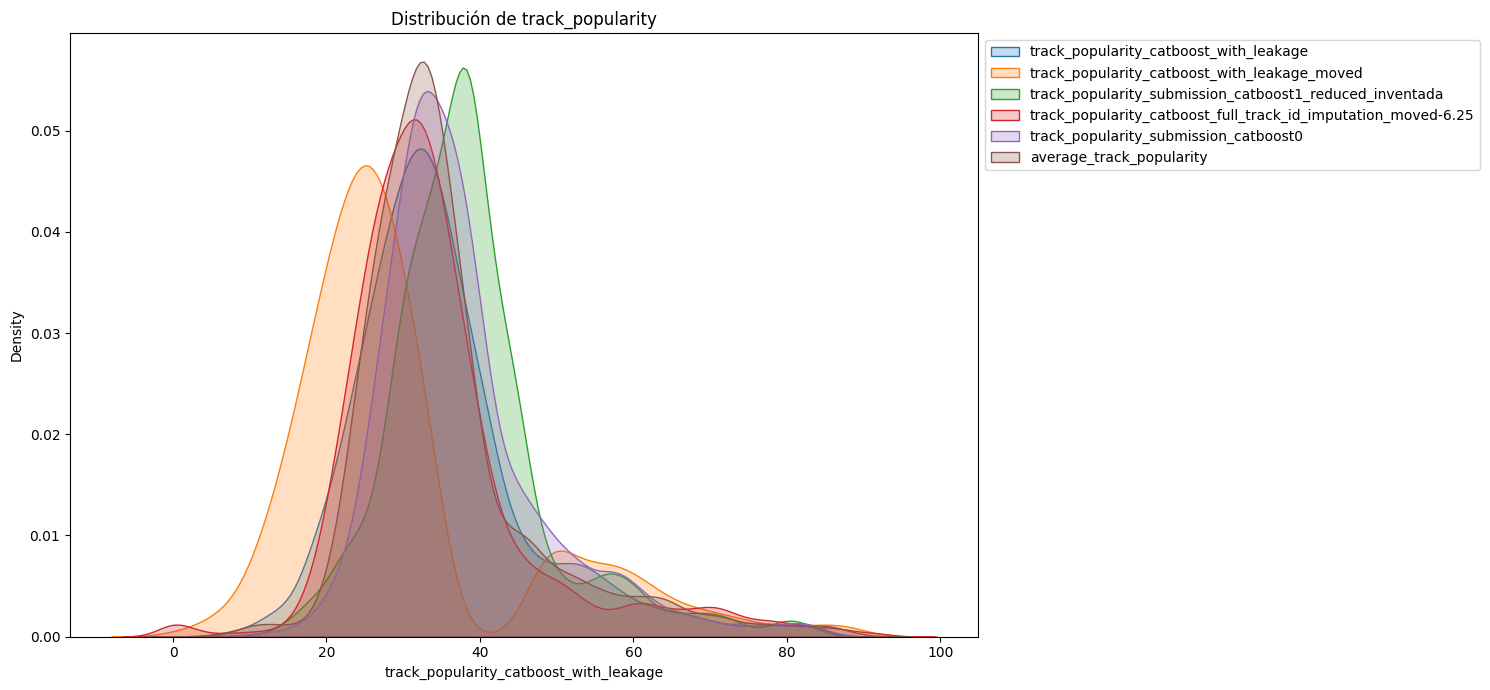

In [ ]:
plt.figure(figsize=(15, 7)) # Increased figure size for better legend placement
for col in merged_df.drop(columns=['ID', 'track_popularity_catboost_full_plus_with_leakage_track_id_moved6.5']).columns:
    sns.kdeplot(merged_df[col], label=f'{col}', fill=True)
plt.title(f'Distribución de track_popularity')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

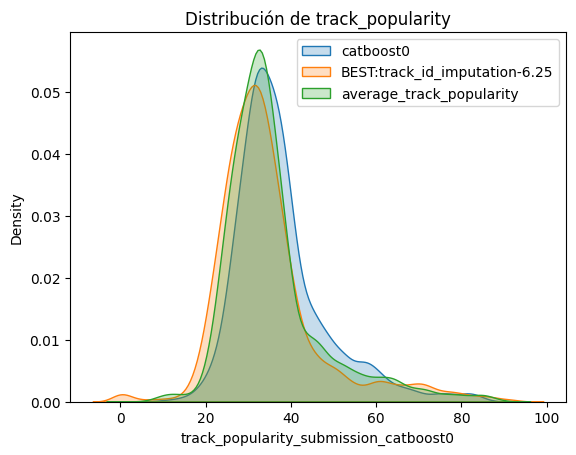

In [ ]:
sns.kdeplot(merged_df['track_popularity_submission_catboost0'], label=f'catboost0', fill=True)
sns.kdeplot(merged_df['track_popularity_catboost_full_track_id_imputation_moved-6.25'], label=f'BEST:track_id_imputation-6.25', fill=True)
sns.kdeplot(merged_df['average_track_popularity'], label=f'average_track_popularity', fill=True)
plt.title(f'Distribución de track_popularity')
plt.legend()
plt.show()

### Promedio predicciones (todas arriba de 0,20)

In [ ]:
import os
import pandas as pd

# Directory where the files are located
directory_path = '/content/'

# Get all CSV files in the directory
all_files_in_dir = [f for f in os.listdir(directory_path) if f.endswith('.csv')]

# Initialize a base dataframe for merging and a list to track used files
merged_df = None
files_used_for_averaging = []

print(f"Searching for relevant CSV files in '{directory_path}'...")

for filename in all_files_in_dir:
    file_path = os.path.join(directory_path, filename)
    try:
        temp_df = pd.read_csv(file_path)
        # Check if 'ID' column exists
        if 'ID' in temp_df.columns:
            # Check if it has exactly two columns
            if len(temp_df.columns) == 2:
                # Assume the second column is 'track_popularity' if it's not named that already
                if temp_df.columns[1] != 'track_popularity':
                    temp_df.rename(columns={temp_df.columns[1]: 'track_popularity'}, inplace=True)

                # Now proceed as if 'track_popularity' column exists
                col_name = f'track_popularity_{filename.replace(".csv", "")}'
                temp_df = temp_df[['ID', 'track_popularity']].rename(columns={'track_popularity': col_name})

                if merged_df is None:
                    merged_df = temp_df
                else:
                    # Perform an inner merge to ensure all IDs are common across submissions
                    merged_df = pd.merge(merged_df, temp_df, on='ID', how='inner')
                files_used_for_averaging.append(filename)
            else:
                print(f"Skipping '{filename}' as it has {len(temp_df.columns)} columns (expected 2 for ID and track_popularity). A 'track_popularity' column was not explicitly found.")
        else:
            print(f"Skipping '{filename}' as it does not contain an 'ID' column.")
    except Exception as e:
        print(f"Error reading '{filename}': {e}")

if merged_df is not None:
    # Get all columns that start with 'track_popularity_'
    popularity_cols = [col for col in merged_df.columns if col.startswith('track_popularity_')]

    if popularity_cols:
        # Calculate the mean of these columns
        merged_df['average_track_popularity'] = merged_df[popularity_cols].mean(axis=1)

        print("\n--- Files used for averaging ---")
        for f in files_used_for_averaging:
            print(f"- {f}")
        print("---------------------------------")

        # Display the head of the new DataFrame with averaged predictions
        print("\nDataFrame with averaged 'track_popularity' columns (first 5 rows):")
        print(merged_df[['ID', 'average_track_popularity']].head())
    else:
        print("No 'track_popularity' columns found to average after merging.")
else:
    print("No relevant CSV files were found or merged successfully to perform averaging.")

Searching for relevant CSV files in '/content/'...

--- Files used for averaging ---
- catboost_with_leakage.csv
- catboost_full_track_id_imputation_moved-8.csv
- probando_inventada.csv
- catboost_with_leakage_moved.csv
- catboost_full_track_id_imputation_moved-7.csv
- submission_catboost1_reduced_inventada.csv
- BestRotationForest_menos10.csv
- catboost_full_plus_with_leakage_track_id_moved6.5.csv
- catboost_full_track_id_imputation_moved-6.25.csv
- catboost_full_plus_with_leakage_no_0_minus8.5.csv
- submission_catboost0.csv
- submission_catboost2_FE.csv
- probando_inventada_xgb.csv
---------------------------------

DataFrame with averaged 'track_popularity' columns (first 5 rows):
      ID  average_track_popularity
0  26266                 30.113387
1  26267                 33.283219
2  26268                 32.086900
3  26269                 28.668500
4  26270                 35.520854


In [ ]:
merged_df[['ID', 'average_track_popularity']].rename(columns={'average_track_popularity':'track_popularity'}).to_csv('averaged_submission_muchas_predicciones.csv', index=False)

Comparamos con el merged anterior

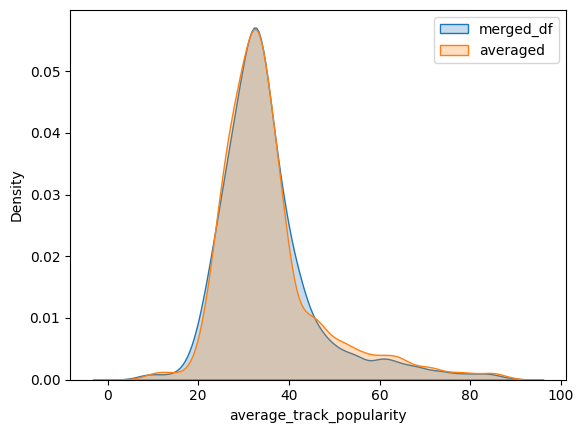

In [ ]:
averaged = pd.read_csv('/content/averaged_submission.csv')

sns.kdeplot(merged_df['average_track_popularity'], label=f'merged_df', fill=True)
sns.kdeplot(averaged['track_popularity'], label=f'averaged', fill=True)
plt.legend()
plt.show()

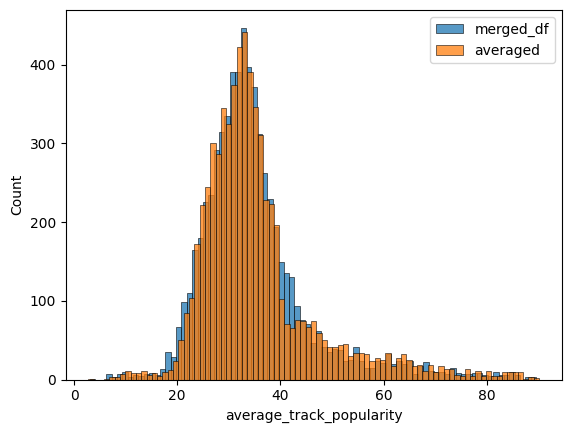

In [ ]:
sns.histplot(merged_df['average_track_popularity'], label=f'merged_df')
sns.histplot(averaged['track_popularity'], label=f'averaged')
plt.legend()
plt.show()

Movemos la mejor prediccion

In [ ]:
avg_best_sub = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/averaged_submission.csv')
full_track_id_imputation = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_full_track_id_imputation_moved-6.25.csv')


In [ ]:
avg_best_sub['track_popularity'].head()

,track_popularity
0,29.107257
1,31.492400
2,30.683630
3,28.491468
4,41.320925


In [ ]:
# avg_best_sub['track_popularity'] = avg_best_sub['track_popularity'] - 3
# avg_best_sub['track_popularity'] = avg_best_sub['track_popularity'].apply(lambda x: 0 if x < 0 else x)

# avg_best_sub['track_popularity'].head()

# avg_best_sub[['ID','track_popularity']].to_csv('avg_submission_moved_-3.csv',index=False)

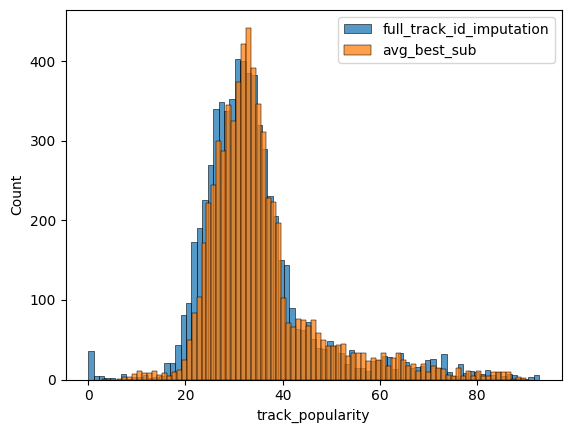

In [ ]:
sns.histplot(full_track_id_imputation['track_popularity'], label=f'full_track_id_imputation')
sns.histplot(avg_best_sub['track_popularity'], label=f'avg_best_sub')
plt.legend()
plt.show()

In [ ]:
df_catboost_classif_reg = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_classif_catboost_reg.csv')

In [ ]:
ids_0_catboost_classif_reg = list(df_catboost_classif_reg[df_catboost_classif_reg['track_popularity'] == 0]['ID'].values)
avg_best_sub.loc[avg_best_sub['ID'].isin(ids_0_catboost_classif_reg)]

,ID,track_popularity
52,26318,8.319908
303,26569,32.146880
304,26570,22.512190
305,26571,39.021721
323,26589,26.697465
...,...,...
6518,32784,25.980425
6544,32810,25.110383
6562,32828,29.644732
6565,32831,24.386832


In [ ]:
ids_0_full_track_id_imp = list(full_track_id_imputation[full_track_id_imputation['track_popularity'] == 0]['ID'].values)
avg_best_sub.loc[avg_best_sub['ID'].isin(ids_0_full_track_id_imp)]

,ID,track_popularity
52,26318,8.319908
114,26380,10.756180
141,26407,9.822889
241,26507,10.721615
1428,27694,10.046321
1442,27708,8.700064
1514,27780,10.794670
1705,27971,11.638797
1711,27977,20.918825
1720,27986,9.654810


In [ ]:
in_ids_0 = (avg_best_sub['ID'].isin(ids_0_full_track_id_imp))
less_than_15 = (avg_best_sub['track_popularity'] < 15)

avg_best_sub.loc[(in_ids_0) & (less_than_15), 'track_popularity'] = 0

In [ ]:
avg_best_sub[['ID', 'track_popularity']].to_csv('avg_submission_imputed_0s.csv',index=False)

### Otros promedios

Repasamos best average_submission

In [102]:
avg = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/main/Submissions/averaged_submission.csv')
avg['track_popularity'].describe()

,track_popularity
count,6567.000000
mean,35.662140
std,11.721925
min,2.748668
25%,28.654682
50%,33.086553
75%,38.376139
max,90.116113


Kaggle: 0.38610

In [94]:
catboost_with_leakage = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_with_leakage.csv')
submission_catboost1_reduced_inventada = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_catboost1_reduced_inventada.csv')
catboost_full_plus_with_leakage_track_id_moved65 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_full_plus_with_leakage_track_id_moved6.5.csv')
catboost_full_track_id_imputation_moved_625 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_full_track_id_imputation_moved-6.25.csv')
submission_catboost0 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_catboost0.csv')

# pd.DataFrame({'ID':catboost_with_leakage['ID'],
#               'track_popularity':((catboost_with_leakage['track_popularity']+
#                                    submission_catboost1_reduced_inventada['track_popularity']
#                                   +catboost_full_plus_with_leakage_track_id_moved65['track_popularity']+
#                                   catboost_full_track_id_imputation_moved_625['track_popularity']+
#                                    submission_catboost0['track_popularity'])/5)
# }).to_csv('avg_sub_with_no_leakage_moved.csv', index=False)

In [95]:
df_prom_5 = pd.DataFrame({'ID':catboost_with_leakage['ID'],
              'track_popularity':((catboost_with_leakage['track_popularity']+
                                   submission_catboost1_reduced_inventada['track_popularity']
                                  +catboost_full_plus_with_leakage_track_id_moved65['track_popularity']+
                                  catboost_full_track_id_imputation_moved_625['track_popularity']+
                                   submission_catboost0['track_popularity'])/5)})

In [98]:
df_prom_5['track_popularity'].describe()

,track_popularity
count,6567.000000
mean,36.779175
std,11.066892
min,3.298402
25%,30.221016
50%,34.536598
75%,39.632770
max,89.827372


Kaggle: 0.39127

In [3]:
catboost_with_leakage = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_with_leakage.csv')
catboost_full_plus_with_leakage_track_id_moved65 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_full_plus_with_leakage_track_id_moved6.5.csv')
catboost_full_track_id_imputation_moved_625 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_full_track_id_imputation_moved-6.25.csv')
submission_catboost0 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_catboost0.csv')

# pd.DataFrame({'ID':catboost_with_leakage['ID'],
#               'track_popularity':((catboost_with_leakage['track_popularity']+
#                                   catboost_full_plus_with_leakage_track_id_moved65['track_popularity']+
#                                   catboost_full_track_id_imputation_moved_625['track_popularity']+
#                                    submission_catboost0['track_popularity'])/4)
# }).to_csv('avg_sub_no_leakageMoved_no_reducedInv.csv', index=False)

In [99]:
df_prom4 = pd.DataFrame({'ID':catboost_with_leakage['ID'],
              'track_popularity':((catboost_with_leakage['track_popularity']+
                                  catboost_full_plus_with_leakage_track_id_moved65['track_popularity']+
                                  catboost_full_track_id_imputation_moved_625['track_popularity']+
                                   submission_catboost0['track_popularity'])/4)})

df_prom4['track_popularity'].describe()

,track_popularity
count,6567.000000
mean,36.341250
std,11.383706
min,2.860776
25%,29.754597
50%,33.912706
75%,38.993109
max,90.860432


Kaggle: 0.38653

In [20]:
catboost_with_leakage = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_with_leakage.csv')
catboost_full_track_id_imputation_moved_625 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_full_track_id_imputation_moved-6.25.csv')
submission_catboost0 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_catboost0.csv')

pd.DataFrame({'ID':catboost_with_leakage['ID'],
              'track_popularity':((catboost_with_leakage['track_popularity']+
                                  catboost_full_track_id_imputation_moved_625['track_popularity']+
                                   submission_catboost0['track_popularity'])/3)
}).to_csv('avg_sub_NO_leakageMoved_reducedInv_leakTrack65.csv', index=False)

Kaggle: ?

In [22]:
catboost_with_leakage = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_with_leakage.csv')
catboost_full_track_id_imputation_moved_625 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_full_track_id_imputation_moved-6.25.csv')

pd.DataFrame({'ID':catboost_with_leakage['ID'],
              'track_popularity':((catboost_with_leakage['track_popularity']+
                                  catboost_full_track_id_imputation_moved_625['track_popularity'])/2)
}).to_csv('avg_leak_plus_track_id.csv', index=False)

Kaggle: ?

In [23]:
catboost_with_leakage = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_with_leakage.csv')
catboost_full_track_id_imputation_moved_625 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/catboost_full_track_id_imputation_moved-6.25.csv')

pd.DataFrame({'ID':catboost_with_leakage['ID'],
              'track_popularity':((catboost_with_leakage['track_popularity']+6+
                                  catboost_full_track_id_imputation_moved_625['track_popularity']+6.25)/2)
}).to_csv('avg_ORIGINALS_leak_plus_track_id.csv', index=False)

Kaggle correr

In [ ]:
catboost0,catboost_with_leakage,catboost1_red_inv

Comparacion Kde Plot

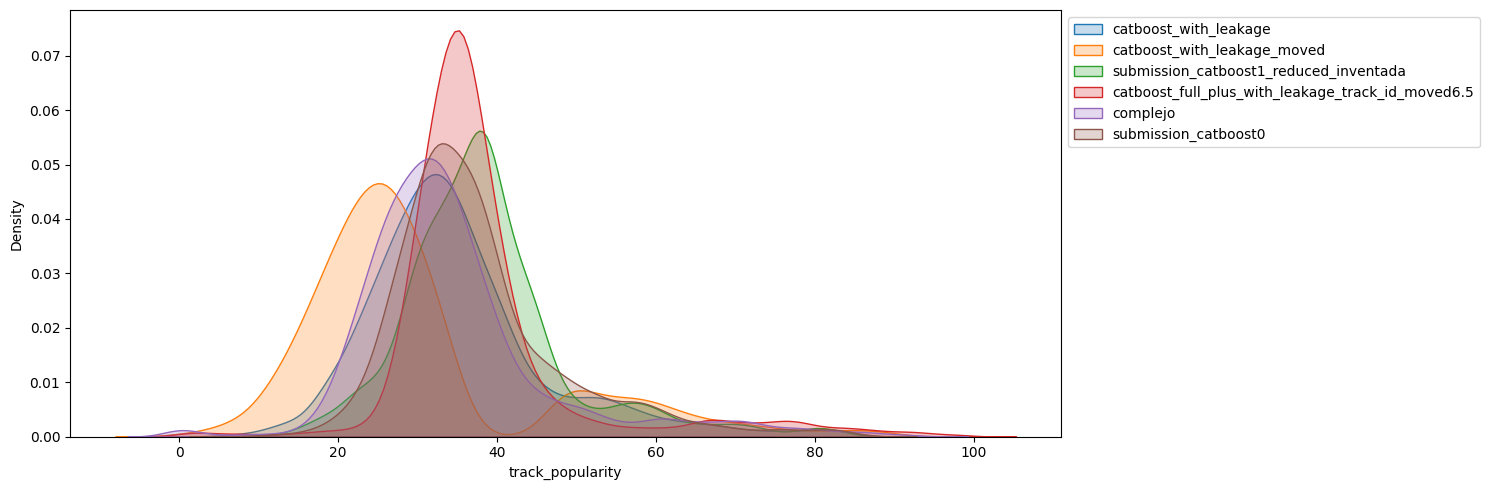

In [19]:
modelos = ['catboost_with_leakage', 'catboost_with_leakage_moved', 'submission_catboost1_reduced_inventada',
           'catboost_full_plus_with_leakage_track_id_moved6.5', 'catboost_full_track_id_imputation_moved-6.25',
           'submission_catboost0']
plt.figure(figsize=(15, 5)) # Increased figure size for better visualization
for i in modelos:
  url_github = f'https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/{i}.csv'
  pop_modelo = pd.read_csv(url_github)['track_popularity']
  if i == 'catboost_full_track_id_imputation_moved-6.25':
    i = 'complejo'
  sns.kdeplot(pop_modelo, label=f'{i}', fill=True)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

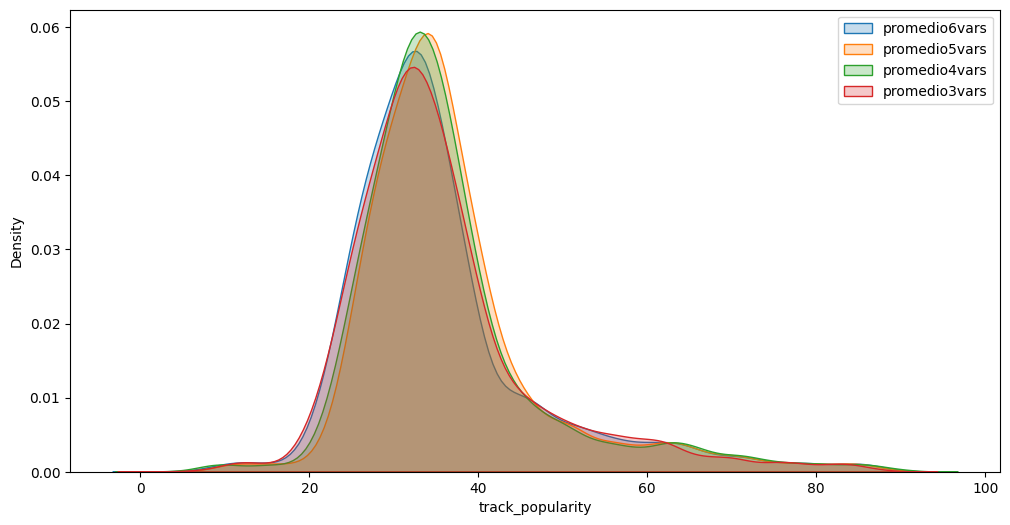

In [21]:
col = 'track_popularity'
promedio6vars = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/averaged_submission.csv')[col]
promedio5vars = (catboost_with_leakage[col]+catboost_full_plus_with_leakage_track_id_moved65[col]+
             catboost_full_track_id_imputation_moved_625[col]+submission_catboost0[col]+
             submission_catboost1_reduced_inventada[col])/5
promedio4vars = (catboost_with_leakage[col]+catboost_full_plus_with_leakage_track_id_moved65[col]+
             catboost_full_track_id_imputation_moved_625[col]+submission_catboost0[col])/4
promedio3vars = (catboost_with_leakage[col]+catboost_full_track_id_imputation_moved_625[col]+submission_catboost0[col])/3

plt.figure(figsize=(12, 6)) # Increased figure size for better visualization
sns.kdeplot(promedio6vars, label='promedio6vars', fill=True)
sns.kdeplot(promedio5vars, label='promedio5vars', fill=True)
sns.kdeplot(promedio4vars, label='promedio4vars', fill=True)
sns.kdeplot(promedio3vars, label='promedio3vars', fill=True)
plt.legend()
plt.show()